In [1]:
# %matplotlib inline

# Standard numerical and visualization libraries
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE  = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN   = "#18453B"  

matplotlib.rc('font',   size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes',   titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes',   labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick',  labelsize=SMALL_SIZE)     # fontsize of the tick labels
matplotlib.rc('ytick',  labelsize=SMALL_SIZE)     # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)      # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)    # fontsize of the figure title

# 2-D Hydrodynamics Solver

This notebook implements a finite-volume hydrodynamics solver for the **2D Euler equations** and applies it to the **Sedov blast wave problem** — a point energy deposition at the domain center that drives a cylindrically symmetric shock wave outward. The initial condition has uniform density, zero velocity everywhere, and a small high-pressure hot spot of radius $r_0$ at the center; as the simulation advances the shock expands symmetrically through the background gas.

---

## The 2D Euler Equations

The Euler equations express conservation of mass, momentum (in x and y), and energy in conservative form:

$$
\mathcal{U}_t + \left[\textbf{F}^{(x)}(\mathcal{U})\right]_x + \left[\textbf{F}^{(y)}(\mathcal{U})\right]_y = 0
$$

with conserved variable vector $\mathcal{U}$ and directional flux vectors $\textbf{F}^{(x)}$, $\textbf{F}^{(y)}$:

$$
\mathcal{U} =
\begin{bmatrix}
\rho \\ \rho u \\ \rho v \\ \rho E
\end{bmatrix}

\qquad

\textbf{F}^{(x)}(\mathcal{U}) =
\begin{bmatrix}
\rho u \\ \rho u^2 + p \\ \rho v u \\ u(\rho E + p)
\end{bmatrix}

\qquad

\textbf{F}^{(y)}(\mathcal{U}) =
\begin{bmatrix}
\rho v \\ \rho u v \\ \rho v^2 + p \\ v(\rho E + p)
\end{bmatrix}
$$

The **conserved variables** are:

- mass density: $\rho(x,y,t)$
- x-momentum density: $\rho u(x,y,t)$
- y-momentum density: $\rho v(x,y,t)$
- total energy density: $\rho E(x,y,t)$

The **primitive (physical) variables** are:

- density: $\rho(x,y,t)$
- x-velocity: $u(x,y,t)$
- y-velocity: $v(x,y,t)$
- pressure: $p(x,y,t)$

> **Array layout:** the solution array has shape `(DOFs, ny, nx)` — the y-index comes before x.

---

## Energetics and Equation of State

$E$ is the **specific total energy** (energy per unit mass):

$$
E = e + \frac{1}{2}(u^2 + v^2)
$$

where $e$ is the specific internal energy. The system is closed by the **gamma-law equation of state**:

$$
p = \rho e (\gamma - 1)
$$

where $\gamma$ is the ratio of specific heats.

In [2]:
# Ghost cells pad all four domain edges so the interior update stencil never accesses
# out-of-bounds indices. nghost=2 supports PLM reconstruction, which looks one cell to each side.
nghost = 2

# The 2D Euler system carries 4 conserved variables: density (ρ), x-momentum density (ρu),
# y-momentum density (ρv), and total energy density (ρE).
DOFs_Sedov = 4  # U = (ρ, ρu, ρv, ρE)
# U.shape = (DOFs, ny, nx)  — y index comes before x

In [3]:
def sedov_blast(U_ghost, gamma, nx, ny, r0=0.01, nsub=4):
    '''
    Definition: initializes the 2D Sedov blast wave problem on a ghosted grid

    Inputs:     U_ghost : zeroed ghosted array of shape (DOFs, ny+2*nghost, nx+2*nghost)
                gamma   : adiabatic index
                nx, ny  : number of interior cells in x and y
                r0      : blast radius — cells whose center lies within r0 of (xc, yc) receive hot pressure
                nsub    : number of sub-cell sample points per dimension for cells that straddle the boundary

    Outputs:    U : conserved variable array with the following IC:
                    U[0] = ρ = 1 everywhere (uniform density)
                    U[1] = U[2] = 0         (zero velocity everywhere)
                    U[3] = ρE = p/(γ-1)     (background pressure p_bg = 1e-5 outside blast,
                                            hot pressure p_hot inside blast radius r0)

    Dependencies: nghost

    Source: Zingale's pyro2 Github (sedov.py)

    The explosion deposits a total energy E_sedov = 1 into a disk of radius r0 centered
    at (xc, yc) = (0.5, 0.5).

    Pressure values:
        p_bg  = 1e-5                          (near-vacuum background)
        p_hot = (γ-1) * E_sedov / (π r0²)   (hot spot pressure derived from total energy)

    Cells fully outside 2*r0 of the center are skipped for efficiency.
    Cells that straddle the blast boundary are handled by sub-sampling:
        an nsub×nsub grid of points is placed inside the cell; p is the area-weighted average
        of p_hot (sub-points with dist ≤ r0) and p_bg (sub-points with dist > r0).
    '''
    dx = 1.0/nx
    dy = 1.0/ny

    xc = 0.5   # blast center x
    yc = 0.5   # blast center y

    E_sedov = 1.0

    p_bg  = 1.e-5                                         # background (near-vacuum) pressure
    p_hot = (gamma-1)*E_sedov / (np.pi * r0**2)           # hot-spot pressure from energy

    U = np.zeros_like(U_ghost)

    U[0,:,:] = 1.0                    # uniform density ρ = 1
    U[3,:,:] = p_bg / (gamma - 1)    # background energy density ρE = p_bg/(γ-1)

    for j in range(nghost, nghost+ny):
        for i in range(nghost, nghost+nx):

            x_l = (i - nghost) * dx   # left edge of cell (i, j) in physical coordinates
            y_l = (j - nghost) * dy

            # skip cells whose center is far from the blast radius (efficiency optimization)
            rc = np.sqrt((x_l + 0.5*dx - xc)**2 + (y_l + 0.5*dy - yc)**2)
            if rc > 2.0*r0:
                continue

            # sub-sample within the cell: nsub×nsub points evenly spaced inside the cell
            xsub = x_l + (dx / nsub) * (np.arange(nsub) + 0.5)
            ysub = y_l + (dy / nsub) * (np.arange(nsub) + 0.5)

            xx, yy = np.meshgrid(xsub, ysub, indexing='ij')
            dist = np.sqrt((xx-xc)**2 + (yy-yc)**2)

            n_in = np.count_nonzero(dist <= r0)   # number of sub-points inside the blast radius

            # area-weighted average pressure: n_in sub-points get p_hot, the rest get p_bg
            p = (n_in * p_hot + (nsub**2 - n_in) * p_bg) / nsub**2

            U[3,j,i] = p / (gamma-1.0)   # update total energy density ρE = p/(γ-1) for this cell

    return U

In [4]:
def fill_ghost_outflow_bc(U, ny, nx):
    '''
    Definition: fills ghost cells on all four domain boundaries with outflow (zero-gradient) BCs

    Inputs:     U  : solution array of shape (DOFs, ny+2*nghost, nx+2*nghost)
                ny : number of interior cells in y
                nx : number of interior cells in x

    Outputs:    U : same array with ghost cells set equal to the nearest interior edge value

    Dependencies: nghost 

    Outflow BC sets each ghost cell equal to the adjacent interior edge value (zero gradient),
    which lets waves exit the domain without spurious reflections.
    Interior cells run from index nghost to nghost+n-1 (inclusive) in each direction.

        left  ghosts : U[:, :, 0:nghost]        = U[:, :, nghost:nghost+1]        (nearest left  column)
        right ghosts : U[:, :, nghost+nx:]      = U[:, :, nghost+nx-1:nghost+nx]  (nearest right column)
        bottom ghosts: U[:, 0:nghost, :]        = U[:, nghost:nghost+1, :]         (nearest bottom row)
        top    ghosts: U[:, nghost+ny:, :]      = U[:, nghost+ny-1:nghost+ny, :]   (nearest top    row)
    '''
    # Left boundary: copy leftmost interior column into left ghost columns
    U[:, :, 0:nghost] = U[:, :, nghost:nghost+1]

    # Right boundary: copy rightmost interior column into right ghost columns
    U[:, :, nghost+nx:] = U[:, :, nghost+nx-1:nghost+nx]

    # Bottom boundary: copy bottommost interior row into bottom ghost rows
    U[:, 0:nghost, :] = U[:, nghost:nghost+1, :]

    # Top boundary: copy topmost interior row into top ghost rows
    U[:, nghost+ny:, :] = U[:, nghost+ny-1:nghost+ny, :]

    return U

In [5]:
def cons_to_prim(U, gamma):
    '''
    Definition: converts conserved variables to primitive variables

    Inputs:     U     : conserved state (ρ, ρu, ρv, ρE)^T (any shape broadcastable array)
                gamma : adiabatic index

    Outputs:    U_prim : primitive state (ρ, u, v, p)^T

    Dependencies: none

    Conversion:
        u = (ρu)/ρ,  v = (ρv)/ρ          (velocity components from momentum densities)
        E = (ρE)/ρ                         (specific total energy)
        e = E - ½(u²+v²)                  (specific internal energy)
        p = ρ e (γ-1)                      (pressure from gamma-law EOS)
    '''
    # Grab conserved variables
    rho_cons   = U[0]
    rho_u_cons = U[1]
    rho_v_cons = U[2]
    rho_E_cons = U[3]

    # New solution vector to return
    U_prim = np.zeros_like(U)

    # Recover primitive variables
    rho_prim = rho_cons
    u_prim   = rho_u_cons / rho_cons                          # x-velocity
    v_prim   = rho_v_cons / rho_cons                          # y-velocity
    E_prim   = rho_E_cons / rho_cons                          # specific total energy
    e_prim   = E_prim - 0.5*(u_prim*u_prim + v_prim*v_prim)  # specific internal energy
    p_prim   = rho_prim * e_prim * (gamma - 1)                # gamma-law pressure

    # Assign primitive variables to output vector
    U_prim[0] = rho_prim
    U_prim[1] = u_prim
    U_prim[2] = v_prim
    U_prim[3] = p_prim

    return U_prim


def prim_to_cons(U, gamma):
    '''
    Definition: converts primitive variables to conserved variables

    Inputs:     U     : primitive state (ρ, u, v, p)^T
                gamma : adiabatic index

    Outputs:    U_cons : conserved state (ρ, ρu, ρv, ρE)^T

    Dependencies: none

    Conversion:
        ρu  = ρ * u,  ρv = ρ * v          (momentum densities)
        ρE  = p/(γ-1) + ½ρ(u²+v²)        (total energy density from gamma-law EOS)
    '''
    # Grab primitive variables
    rho_prim = U[0]
    u_prim   = U[1]
    v_prim   = U[2]
    p_prim   = U[3]

    # New solution vector to return
    U_cons = np.zeros_like(U)

    # Assemble conserved variables
    rho_cons   = rho_prim
    rho_u_cons = rho_prim * u_prim                                      # x-momentum density
    rho_v_cons = rho_prim * v_prim                                      # y-momentum density
    rho_E_cons = p_prim/(gamma-1) + 0.5*rho_prim*(u_prim**2 + v_prim**2)  # total energy density

    # Assign conserved variables to output vector
    U_cons[0] = rho_cons
    U_cons[1] = rho_u_cons
    U_cons[2] = rho_v_cons
    U_cons[3] = rho_E_cons

    return U_cons

In [6]:
def compute_flux_x(q, gamma):
    '''
    Definition: evaluates the x-direction Euler flux vector F^(x)(U)

    Inputs:     q     : conserved state (ρ, ρu, ρv, ρE)^T
                gamma : adiabatic index

    Outputs:    F : x-direction flux vector

        F[0] = ρu           (mass flux in x)
        F[1] = ρu² + p      (x-momentum flux)
        F[2] = ρvu          (y-momentum advected in x)
        F[3] = u(ρE + p)    (energy flux in x)

    Dependencies: cons_to_prim

    Reference: Zingale eq. 8.77
    '''
    q_prim = cons_to_prim(q, gamma)

    rho = q_prim[0]
    u   = q_prim[1]
    v   = q_prim[2]
    p   = q_prim[3]

    E = p / (rho * (gamma - 1)) + 0.5 * (u**2 + v**2)   # specific total energy
    F = np.zeros_like(q)
    F[0] = rho * u                  # mass flux in x
    F[1] = rho * u*u + p            # x-momentum flux
    F[2] = rho * v * u              # y-momentum advected in x-direction
    F[3] = rho * u * E + u * p      # energy flux in x: u*(ρE + p)

    return F


def compute_flux_y(q, gamma):
    '''
    Definition: evaluates the y-direction Euler flux vector F^(y)(U)

    Inputs:     q     : conserved state (ρ, ρu, ρv, ρE)^T
                gamma : adiabatic index

    Outputs:    F : y-direction flux vector

        F[0] = ρv           (mass flux in y)
        F[1] = ρuv          (x-momentum advected in y)
        F[2] = ρv² + p      (y-momentum flux)
        F[3] = v(ρE + p)    (energy flux in y)

    Dependencies: cons_to_prim

    Reference: Zingale eq. 8.77
    '''
    q_prim = cons_to_prim(q, gamma)

    rho, u, v, p = q_prim[0], q_prim[1], q_prim[2], q_prim[3]

    E = p / (rho * (gamma - 1)) + 0.5 * (u**2 + v**2)   # specific total energy
    F = np.zeros_like(q)
    F[0] = rho * v                  # mass flux in y
    F[1] = rho * u * v              # x-momentum advected in y-direction
    F[2] = rho * v*v + p            # y-momentum flux
    F[3] = rho * v * E + v * p      # energy flux in y: v*(ρE + p)

    return F

# HLL Riemann Solver

At each cell interface, the finite-volume update requires a numerical flux $F_{i+1/2}$ or $F_{j+1/2}$. An **approximate Riemann solver** replaces the exact multi-wave Riemann fan with a simpler wave structure that still satisfies the integral form of the conservation law.

## Two-Wave (HLL) Approximation

The **HLL solver** represents the Riemann fan with just two bounding waves — a leftmost wave $S_L$ and a rightmost wave $S_R$ — enclosing a single averaged intermediate state:

```
          t
          ^
          |
   S_L    |    S_R
     \    |    /
      \   |   /
       \  |  /
  U_L   \ | /   U_R
          \|/
  ---------+----------> normal direction
           0
```

In 2D, the solver is called with a `space` parameter (`'x'` or `'y'`) that selects the **normal direction** for each interface:
- `space='x'`: solving at a face normal to x; uses `u` as the normal velocity and `compute_flux_x`
- `space='y'`: solving at a face normal to y; uses `v` as the normal velocity and `compute_flux_y`

Wave speeds are estimated from the left/right sound speeds $c_{L,R} = \sqrt{\gamma p / \rho}$ and the normal velocity component.

*HLL scheme modeled after Carolyn's 1D code.*

In [7]:
def Riemann_HLL(U_L, U_R, gamma, space):
    '''
    Definition: computes the HLL approximate Riemann flux for the 2D Euler equations

    Inputs:     U_L   : left  conserved state (ρ, ρu, ρv, ρE)^T
                U_R   : right conserved state (ρ, ρu, ρv, ρE)^T
                gamma : adiabatic index
                space : 'x' — interface normal to x (uses u as normal velocity, compute_flux_x)
                        'y' — interface normal to y (uses v as normal velocity, compute_flux_y)

    Outputs:    flux : HLL flux vector at the interface (same shape as U_L)

    Dependencies: cons_to_prim, compute_flux_x, compute_flux_y
    '''

    ################################################################################################
    # 1) Convert to primitive variables for wave-speed estimation; keep conserved copies for flux
    ################################################################################################

    U_L_cons = U_L.copy()
    U_R_cons = U_R.copy()

    U_L = cons_to_prim(U_L, gamma)
    U_R = cons_to_prim(U_R, gamma)

    rho_L = U_L[0]; u_L = U_L[1]; v_L = U_L[2]; p_L = U_L[3]
    rho_R = U_R[0]; u_R = U_R[1]; v_R = U_R[2]; p_R = U_R[3]

    ################################################################################################
    # 2) Compute left and right sound speeds  c = sqrt(γp/ρ)
    ################################################################################################

    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    ################################################################################################
    # 3) Evaluate physical fluxes and estimate bounding wave speeds from normal velocity component
    #    space='x': normal velocity is u  →  s_l = min(u_L-c_L, u_R-c_R)
    #    space='y': normal velocity is v  →  s_l = min(v_L-c_L, v_R-c_R)
    ################################################################################################

    if space == 'x':
        F_L = compute_flux_x(U_L_cons, gamma)
        F_R = compute_flux_x(U_R_cons, gamma)
        s_l = min(u_L - c_L, u_R - c_R)   # leftmost  wave speed in x
        s_r = max(u_L + c_L, u_R + c_R)   # rightmost wave speed in x
    elif space == 'y':
        F_L = compute_flux_y(U_L_cons, gamma)
        F_R = compute_flux_y(U_R_cons, gamma)
        s_l = min(v_L - c_L, v_R - c_R)   # leftmost  wave speed in y
        s_r = max(v_L + c_L, v_R + c_R)   # rightmost wave speed in y
    else:
        print('error in Riemann flux with space vars')

    ################################################################################################
    # 4) Apply HLL upwinding based on wave speed signs
    ################################################################################################

    if s_l >= 0:
        flux = F_L
    elif s_r <= 0:
        flux = F_R
    else:
        flux = (s_r * F_L - s_l * F_R + s_l * s_r * (U_R_cons - U_L_cons)) / (s_r - s_l)

    return flux

# HLLC Riemann Solver

## Motivation: Restoring the Contact Wave

- **Left state** $U_L$: for characteristics moving faster than $S_L$ to the right
- **Left star state** $U^*_L$: between $S_L$ and $S^*$
- **Right star state** $U^*_R$: between $S^*$ and $S_R$
- **Right state** $U_R$: for characteristics moving faster than $S_R$ to the left

The `space` parameter (`'x'` or `'y'`) works the same as in `Riemann_HLL` — it selects the normal velocity component for wave speed estimation and picks the appropriate flux function.

*After Toro explanation Chapter 10*

In [8]:
def U_star_s(U_s, rho_s, u_s, v_s, p_s, E_s, S_s, S_star, space):
    '''
    Definition: computes the HLLC intermediate (star) state on one side of the contact wave

    Inputs:     U_s    : conserved state on side s — (ρ, ρu, ρv, ρE)^T
                rho_s  : density on side s
                u_s    : x-velocity on side s
                v_s    : y-velocity on side s
                p_s    : pressure on side s
                E_s    : total energy density (ρE) on side s
                S_s    : bounding wave speed on side s (S_L or S_R)
                S_star : contact wave speed S*
                space  : 'x' — normal direction is x; S* replaces u, v passes through unchanged
                         'y' — normal direction is y; S* replaces v, u passes through unchanged

    Outputs:    U_star_s : intermediate conserved state (ρ*, ρ*u*, ρ*v*, ρ*E*)^T

    Dependencies: none

    Reference: Toro eq. 10.39

    The common density factor is ρ*(S_s - u_normal)/(S_s - S*) where u_normal is u (x) or v (y).
    The normal momentum slot gets ρ* · S* (contact speed).
    The tangential momentum slot carries the tangential velocity unchanged through the contact.
    '''
    U_star_s = np.zeros_like(U_s)

    if space == 'x':
        factor = rho_s * (S_s - u_s)/(S_s - S_star)   # density factor (Toro eq. 10.39)

        U_star_s[0] = factor                            # ρ*
        U_star_s[1] = factor * S_star                   # ρ*u* = ρ* · S*  (normal momentum)
        U_star_s[2] = factor * v_s                      # ρ*v* = ρ* · v_s (tangential, passes through)
        U_star_s[3] = factor * (E_s/rho_s + (S_star - u_s)*(S_star + p_s/(rho_s*(S_s - u_s))))  # ρ*E* (10.39 Toro)

    if space == 'y':
        factor = rho_s * (S_s - v_s)/(S_s - S_star)   # density factor (Toro eq. 10.39)

        U_star_s[0] = factor                            # ρ*
        U_star_s[1] = factor * u_s                      # ρ*u* = ρ* · u_s (tangential, passes through)
        U_star_s[2] = factor * S_star                   # ρ*v* = ρ* · S*  (normal momentum)
        U_star_s[3] = factor * (E_s/rho_s + (S_star - v_s)*(S_star + p_s/(rho_s*(S_s - v_s))))  # ρ*E* (10.39 Toro)

    return U_star_s


def Riemann_HLLC(U_L, U_R, gamma, space):
    '''
    Definition: computes the HLLC approximate Riemann flux for the 2D Euler equations

    Inputs:     U_L   : left  conserved state (ρ, ρu, ρv, ρE)^T
                U_R   : right conserved state (ρ, ρu, ρv, ρE)^T
                gamma : adiabatic index
                space : 'x' — interface normal to x (uses u as normal velocity)
                        'y' — interface normal to y (uses v as normal velocity)

    Outputs:    flux : HLLC flux vector at the interface (same shape as U_L)

    Dependencies: cons_to_prim, compute_flux_x, compute_flux_y, U_star_s

    Reference: Toro eqs. 10.37 (S*), 10.38 (F* from F and U*), 10.39 (U* star state)
    '''

    ################################################################################################
    # 1) Convert to primitive variables
    ################################################################################################

    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)

    rho_L = U_L_prim[0]; u_L = U_L_prim[1]; v_L = U_L_prim[2]; p_L = U_L_prim[3]
    rho_R = U_R_prim[0]; u_R = U_R_prim[1]; v_R = U_R_prim[2]; p_R = U_R_prim[3]

    ################################################################################################
    # 2) Compute left and right sound speeds  c = sqrt(γp/ρ)
    ################################################################################################

    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)

    ################################################################################################
    # 3) Estimate bounding wave speeds S_L, S_R and contact speed S* from normal velocity
    ################################################################################################

    if space == 'x':
        S_L    = min(u_L - c_L, u_R - c_R)                  # leftmost wave speed
        S_R    = max(u_L + c_L, u_R + c_R)                  # rightmost wave speed
        S_star = (p_R - p_L + rho_L * u_L * (S_L - u_L) - rho_R * u_R * (S_R - u_R)) / \
                 (rho_L*(S_L-u_L) - rho_R*(S_R-u_R))        # contact wave speed (10.37 Toro)

        ############################################################################################
        # 4) Evaluate physical fluxes F_L and F_R
        ############################################################################################

        F_L = compute_flux_x(U_L, gamma)
        F_R = compute_flux_x(U_R, gamma)

        ############################################################################################
        # 5) Compute HLLC star states U* and star fluxes F* = F_s + S_s*(U*_s - U_s)  (10.38 Toro)
        ############################################################################################

        rho_E_L = U_L[3]
        rho_E_R = U_R[3]

        U_star_L = U_star_s(U_L, rho_L, u_L, v_L, p_L, rho_E_L, S_L, S_star, space)
        F_star_L = F_L + S_L*(U_star_L - U_L)   # (10.38 Toro)

        U_star_R = U_star_s(U_R, rho_R, u_R, v_R, p_R, rho_E_R, S_R, S_star, space)
        F_star_R = F_R + S_R*(U_star_R - U_R)   # (10.38 Toro)

    elif space == 'y':
        S_L    = min(v_L - c_L, v_R - c_R)                  # leftmost wave speed
        S_R    = max(v_L + c_L, v_R + c_R)                  # rightmost wave speed
        S_star = (p_R - p_L + rho_L * v_L * (S_L - v_L) - rho_R * v_R * (S_R - v_R)) / \
                 (rho_L*(S_L-v_L) - rho_R*(S_R-v_R))        # contact wave speed (10.37 Toro)

        F_L = compute_flux_y(U_L, gamma)
        F_R = compute_flux_y(U_R, gamma)

        rho_E_L = U_L[3]
        rho_E_R = U_R[3]

        U_star_L = U_star_s(U_L, rho_L, u_L, v_L, p_L, rho_E_L, S_L, S_star, space)
        F_star_L = F_L + S_L*(U_star_L - U_L)   # (10.38 Toro)

        U_star_R = U_star_s(U_R, rho_R, u_R, v_R, p_R, rho_E_R, S_R, S_star, space)
        F_star_R = F_R + S_R*(U_star_R - U_R)   # (10.38 Toro)

    else:
        print('error in HLLC riemann with space')

    ################################################################################################
    # 6) Select flux based on which region x/t = 0 falls in
    ################################################################################################

    if S_L >= 0:
        flux = F_L
    elif (S_L <= 0 <= S_star):
        flux = F_star_L
    elif (S_star <= 0 <= S_R):
        flux = F_star_R
    else:
        flux = F_R

    return flux

In [9]:
def piecewise_constant(U):
    '''
    Definition: first-order (piecewise constant) reconstruction — Godunov's method

    Inputs:     U : conserved variable array of shape (DOFs, ny+2*nghost, nx+2*nghost)

    Outputs:    U_L, U_R : both equal to U (the cell-average value is used as both left and
                right interface states; no spatial variation is assumed within each cell)

    Dependencies: none
    '''
    return U, U

In [10]:
def minmod(a, b):  # vectorized like Carolyn's so input can be vector valued
    '''
    Definition: minmod slope limiter — returns the smaller-magnitude slope when both
                inputs agree in sign, and zero when they disagree (local extremum)

    Inputs:     a, b : forward and backward difference arrays 

    Outputs:    slope : limited slope; zero where a and b have opposite signs,
                        the smaller-magnitude value otherwise

    Sign table:
        a > 0, b > 0  →  min(a, b)    (both positive: pick shallower slope)
        a < 0, b < 0  →  max(a, b)    (both negative: pick smaller magnitude)
        sign(a) ≠ sign(b)  →  0       (local extremum: flatten to avoid new extrema)
    '''
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))


def compute_interface_states_PLM_x(U, ds, dt, gamma):
    '''
    Definition: PLM reconstruction along x — slopes limited in primitive space, output in conserved

    Inputs:     U     : conserved array (DOFs, ny+2*nghost, nx+2*nghost)
                ds    : cell size in x (unused in spatial-only PLM)
                dt    : time step (unused)
                gamma : adiabatic index

    Outputs:    U_L, U_R : left/right interface state arrays in conserved form
                U_L[:,:,i] = state extrapolated to the right face of column i (from the left)
                U_R[:,:,i] = state extrapolated to the left  face of column i (from the right)

    Dependencies: cons_to_prim, prim_to_cons, minmod, nghost

    Note: reconstruction is performed in primitive variables (rho, u, v, p) 
    '''
    n = U.shape[2]
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    U = cons_to_prim(U, gamma)   

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,:,i+1] - U[:,:,i]              # forward  difference (delta+)
        dr = U[:,:,i] - U[:,:,i-1]              # backward difference (delta-)

        slope = minmod(dl, dr)                   # limited slope (zero at local extrema)

        U_L[:,:,i] = U[:,:,i] + 0.5 * slope     # extrapolate to right face of cell i
        U_R[:,:,i] = U[:,:,i] - 0.5 * slope     # extrapolate to left  face of cell i

    U_L[:,:,0] = U[:,:,0]   # leftmost ghost column: no extrapolation
    U_R[:,:,0] = U[:,:,0]

    U_L = prim_to_cons(U_L, gamma)   # return interface states in conserved form
    U_R = prim_to_cons(U_R, gamma)

    return U_L, U_R


def compute_interface_states_PLM_y(U, ds, dt, gamma):
    '''
    Definition: PLM reconstruction along y — slopes limited in primitive space, output in conserved

    Inputs:     U     : conserved array (DOFs, ny+2*nghost, nx+2*nghost)
                ds    : cell size in y (unused)
                dt    : time step (unused)
                gamma : adiabatic index

    Outputs:    U_L, U_R : left/right interface state arrays in conserved form
                U_L[:,j,:] = state extrapolated to the top    face of row j (from below)
                U_R[:,j,:] = state extrapolated to the bottom face of row j (from above)

    Dependencies: cons_to_prim, prim_to_cons, minmod, nghost

    Note: same primitive-space reconstruction as compute_interface_states_PLM_x, applied
        along the y direction (index j) rather than x.
    '''
    n = U.shape[1]
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    U = cons_to_prim(U, gamma)   

    for i in range(nghost - 1, n - nghost + 1):
        dl = U[:,i+1,:] - U[:,i,:]              # forward  difference (delta+) along y
        dr = U[:,i,:] - U[:,i-1,:]              # backward difference (delta-) along y

        slope = minmod(dl, dr)                   # limited slope

        U_L[:,i,:] = U[:,i,:] + 0.5 * slope     # extrapolate to top    face of row i
        U_R[:,i,:] = U[:,i,:] - 0.5 * slope     # extrapolate to bottom face of row i

    U_L[:,0,:] = U[:,0,:]   # bottommost ghost row: no extrapolation (U is primitive at this point)
    U_R[:,0,:] = U[:,0,:]

    U_L = prim_to_cons(U_L, gamma)   # return interface states in conserved form
    U_R = prim_to_cons(U_R, gamma)
    return U_L, U_R


def piecewise_linear_x(U, ds, dt, gamma):
    '''
    Definition: thin wrapper — calls compute_interface_states_PLM_x and returns its result

    Inputs:     U, ds, dt, gamma : passed directly to compute_interface_states_PLM_x

    Outputs:    U_L, U_R : left/right conserved interface states along x
    '''
    U_L, U_R = compute_interface_states_PLM_x(U, ds, dt, gamma)
    return U_L, U_R


def piecewise_linear_y(U, ds, dt, gamma):
    '''
    Definition: thin wrapper — calls compute_interface_states_PLM_y and returns its result

    Inputs:     U, ds, dt, gamma : passed directly to compute_interface_states_PLM_y

    Outputs:    U_L, U_R : left/right conserved interface states along y
    '''
    U_L, U_R = compute_interface_states_PLM_y(U, ds, dt, gamma)
    return U_L, U_R

In [11]:

def evolve(U_ghosted, nx, ny, C, t_final, gamma, Riemann, Godunov_type):
    '''
    Definition: advances the 2D Euler equations in time using a Godunov finite-volume scheme
                with transverse-flux-corrected interface states (Zingale §8.6)

    Inputs:     U_ghosted    : initial ghosted conserved array (DOFs, ny+2*nghost, nx+2*nghost)
                nx, ny       : number of interior cells in x and y
                C            : CFL number (stability requires C < 1)
                t_final      : final simulation time
                gamma        : adiabatic index
                Riemann      : callable — Riemann solver (Riemann_HLL or Riemann_HLLC)
                Godunov_type : 0 = piecewise constant (1st-order), 1 = PLM (2nd-order)

    Outputs:    U_interior : final interior conserved state — shape (DOFs, ny, nx)
                all_solns  : list of interior snapshots at each time step (for animation)
                all_t      : list of corresponding simulation times

    Dependencies: fill_ghost_outflow_bc, cons_to_prim, piecewise_constant, piecewise_linear_x,
                  piecewise_linear_y, nghost

    Algorithm overview (Zingale §8.6 Multi-dimensional Problems):
        Each time step proceeds in seven stages:
        1. Apply outflow BCs on all four domain edges
        2. Estimate CFL-limited dt; clip to not overshoot t_final
        3. Reconstruct left/right interface states with the chosen Godunov type
        4. Compute transverse-flux-corrected x-interface states (Zingale eqs. 8.72–8.75)
        5. Compute transverse-flux-corrected y-interface states (same pattern, perpendicular)
        6. Conservative update: U^(n+1) = U^n - (dt/dx)(F_x_i - F_x_{i-1}) - (dt/dy)(F_y_j - F_y_{j-1}) (Zingale 8.78)
        7. Advance time; store interior snapshot
    '''
    dx = 1.0 / nx
    dy = 1.0 / ny

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    
    all_solns.append(U[:, nghost:nghost+ny, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:

        ############################################################################################
        # 1) Apply outflow BCs on all four ghost-cell boundaries
        ############################################################################################

        fill_ghost_outflow_bc(U, ny, nx)

        ############################################################################################
        # 2) CFL-limited time step: dt = C*dx / max(|u|+c, |v|+c); clip to not overshoot t_final
        ############################################################################################

        U_prim = cons_to_prim(U[:, nghost:nghost+ny, nghost:nghost+nx], gamma) #U(rho, u, v, p)
        c = np.sqrt(gamma*U_prim[3]/U_prim[0]) # sound speed in medium 
        max_speed = np.max(np.maximum(np.abs(U_prim[1]) + c, 
                                    np.abs(U_prim[2]) + c))
        dt = C * dx / max_speed  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly

        ############################################################################################
        # 3) Reconstruct interface states with the chosen Godunov type
        ############################################################################################

        if Godunov_type == 0: # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
            U_L, U_R = piecewise_constant(U)
        if Godunov_type == 1:
            U_L_x_hat, U_R_x_hat = piecewise_linear_x(U, dx, dt, gamma) #returns cons
            U_L_y_hat, U_R_y_hat = piecewise_linear_y(U, dy, dt, gamma) #returns cons

        ############################################################################################
        # 4) Transverse-flux-corrected x-interface states (Zingale §8.6, eqs. 8.72–8.75):
        #    a) Compute y-direction transverse fluxes at each interface (j,i)     (eqs. 8.72, 8.73)
        #    b) Correct x-interface states with half-step transverse contribution (eqs. 8.74, 8.75)
        #    c) Riemann solve in x using corrected states to get F_x
        ############################################################################################

        # All this is modeled after Zingale's section 8.6 Multi-dimensional Problems
        # do the x interface 
        F_x = np.zeros_like(U)
        F_T_y_plus = np.zeros_like(U)
        F_T_y_minus = np.zeros_like(U)
        q_x_L = np.zeros_like(U)
        q_x_R = np.zeros_like(U)
        for j in range(nghost-1, nghost+ny):    
            for i in range(nghost-1, nghost+nx+1):
                F_T_y_plus[:,j,i] = Riemann(U_L_y_hat[:,j,i], U_R_y_hat[:,j+1,i],gamma, 'y') # 8.72 returns cons flux
                F_T_y_minus[:,j,i]= Riemann(U_L_y_hat[:,j-1,i], U_R_y_hat[:,j,i],gamma, 'y') # 8.73 returns cons flux 

        for j in range(nghost-1, nghost+ny):    
            for i in range(nghost-1, nghost+nx):
                q_x_L[:,j,i] = U_L_x_hat[:, j, i  ] - 0.5*dt/dy * (F_T_y_plus[:,j,i  ] - F_T_y_minus[:,j,i  ]) # 8.74
                q_x_R[:,j,i] = U_R_x_hat[:, j, i+1] - 0.5*dt/dy * (F_T_y_plus[:,j,i+1] - F_T_y_minus[:,j,i+1]) # 8.75
                #calculate Riemann flux
                F_x[:,j,i] = Riemann(q_x_L[:,j,i], q_x_R[:,j,i],gamma, 'x') #returns cons flux

        ############################################################################################
        # 5) Transverse-flux-corrected y-interface states (same pattern, perpendicular direction):
        #    a) Compute x-direction transverse fluxes at each interface (j,i)     (eqs. 8.72, 8.73)
        #    b) Correct y-interface states with half-step transverse contribution (eqs. 8.74, 8.75)
        #    c) Riemann solve in y using corrected states to get F_y
        ############################################################################################

        # do the y interface stuff
        F_y = np.zeros_like(U)
        F_T_x_plus = np.zeros_like(U)
        F_T_x_minus = np.zeros_like(U)
        q_y_L = np.zeros_like(U)
        q_y_R = np.zeros_like(U)
        for i in range(nghost-1, nghost+nx):  
            for j in range(nghost-1, nghost+ny+1):
                F_T_x_plus[:,j,i] = Riemann(U_L_x_hat[:,j,i  ], U_R_x_hat[:,j,i+1],gamma, 'x') # 8.72 returns cons flux
                F_T_x_minus[:,j,i]= Riemann(U_L_x_hat[:,j,i-1], U_R_x_hat[:,j,i  ],gamma, 'x') # 8.73 returns cons flux   
        
        for i in range(nghost-1, nghost+nx):  
            for j in range(nghost-1, nghost+ny):
                q_y_L[:,j,i] = U_L_y_hat[:, j, i  ] - 0.5*dt/dx * (F_T_x_plus[:,j,i  ] - F_T_x_minus[:,j,i  ]) # 8.74
                q_y_R[:,j,i] = U_R_y_hat[:, j+1, i] - 0.5*dt/dx * (F_T_x_plus[:,j+1,i] - F_T_x_minus[:,j+1,i]) # 8.75
                #calculate Riemann flux
                F_y[:,j,i] = Riemann(q_y_L[:,j,i], q_y_R[:,j,i],gamma, 'y') #returns cons

        ############################################################################################
        # 6) Conservative update: U^(n+1) = U^n - (dt/dx)(F_x_i - F_x_{i-1})
        #                                        - (dt/dy)(F_y_j - F_y_{j-1}) (Zingale 8.78)
        ############################################################################################

        for j in range(nghost, nghost+ny):
            for i in range(nghost, nghost+nx):
                U[:,j, i] = U[:,j, i] - (dt/dx) * (F_x[:,j, i] - F_x[:, j, i-1]) - (dt/dy) * (F_y[:,j,i] - F_y[:,j-1,i])

        ############################################################################################
        # 7) Advance time; store interior snapshot for animation
        ############################################################################################

        t += dt
        
        all_solns.append(U[:, nghost:nghost+ny, nghost:nghost+nx].copy())
        all_t.append(t)

    return U[:, nghost:nghost+ny, nghost:nghost+nx], all_solns, all_t

In [12]:
def plot_solution(X, Y, U_Sol, t, gamma, case='Sedov', Godunov_type='Piecewise Linear', Riemann='HLL'):
    '''
    Definition: plots the 2D Euler solution as a 2x2 grid of colormaps

    Inputs:     X, Y         : 1D coordinate arrays for x and y axes (length nx, ny respectively)
                U_Sol        : conserved variable array (DOFs, ny, nx) — interior cells only
                t            : simulation time (used in the plot title)
                gamma        : adiabatic index
                case         : problem name for the plot title (default 'Sedov')
                Godunov_type : reconstruction label for the title (default 'Piecewise Linear')
                Riemann      : solver label for the title (default 'HLL')

    Outputs:    matplotlib figure with 2x2 subplots (displayed via plt.show()):
                  top-left     : density rho
                  top-right    : speed |U| = sqrt(u^2 + v^2)
                  bottom-left  : pressure p
                  bottom-right : specific internal energy e = E - 0.5*(u^2+v^2)

    Dependencies: numpy, matplotlib
    '''
    rho_sol   = U_Sol[0]
    rho_u_sol = U_Sol[1]
    rho_v_sol = U_Sol[2]
    rho_E_sol = U_Sol[3]

    u_sol   = rho_u_sol / rho_sol
    v_sol   = rho_v_sol / rho_sol
    speed   = np.sqrt(u_sol**2 + v_sol**2)
    E_sol   = rho_E_sol / rho_sol
    e_sol   = E_sol - 0.5 * (u_sol**2 + v_sol**2)
    p_sol   = rho_sol * e_sol * (gamma - 1)

    fields = [
        (rho_sol, r'$\rho$'),
        (speed,   r'$U$'),
        (p_sol,   r'$p$'),
        (e_sol,   r'$e$'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=150)
    fig.suptitle(f'{case} Sedov Blast at t = {t:.2f}  [{Godunov_type}] [{Riemann}]')

    extent = [X[0], X[-1], Y[0], Y[-1]]

    for ax, (field, title) in zip(axes.flat, fields):
        im = ax.imshow(field, origin='lower', extent=extent, aspect='equal', cmap='viridis')
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

    plt.tight_layout()
    plt.show()

In [13]:
def movie_maker(X, Y, all_solns, all_t, gamma, case='Sedov', Riemann='HLLC'):
    '''
    Definition: creates an animated GIF of the 2D Euler solution showing density, speed,
                pressure, and specific internal energy

    Inputs:     X, Y      : 1D coordinate arrays for x and y axes (length nx, ny)
                all_solns : list of conserved variable snapshots (DOFs, ny, nx) from evolve()
                all_t     : list of simulation times corresponding to each snapshot
                gamma     : adiabatic index
                case      : problem name — used in the title and output filename
                Riemann   : solver label — used in the title and output filename

    Outputs:    saves {case}_{Riemann}.gif to the current directory at 15 fps via pillow

    Notes: The inner animate(i) function is the per-frame callback for FuncAnimation.
        Each frame updates the four imshow artists in place for efficiency.
        Color limits are updated per-frame so matplotlib auto-scales to the data range.
    '''
    n_steps = len(all_t)
    extent  = [X[0], X[-1], Y[0], Y[-1]]

    titles = [r'$\rho$', r'$U$', r'$p$', r'$e$']

    # extract fields from the first frame for initialization
    U_0   = all_solns[0]
    rho_0 = U_0[0]
    u_0   = U_0[1] / rho_0
    v_0   = U_0[2] / rho_0
    e_0   = U_0[3] / rho_0 - 0.5*(u_0**2 + v_0**2)
    p_0   = rho_0 * e_0 * (gamma - 1)
    spd_0 = np.sqrt(u_0**2 + v_0**2)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=100)
    title_obj = fig.suptitle(f'{case} at t = 0.000  [{Riemann}]')

    ims = []
    for ax, title, field in zip(axes.flat, titles, [rho_0, spd_0, p_0, e_0]):
        im = ax.imshow(field, origin='lower', extent=extent, aspect='equal', cmap='viridis')
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ims.append(im)

    plt.tight_layout()

    def animate(i):
        U   = all_solns[i]
        rho = U[0]
        u   = U[1] / rho
        v   = U[2] / rho
        e   = U[3] / rho - 0.5*(u**2 + v**2)
        p   = rho * e * (gamma - 1)
        spd = np.sqrt(u**2 + v**2)

        for im, field in zip(ims, [rho, spd, p, e]):
            im.set_data(field)
            im.set_clim(field.min(), field.max())

        title_obj.set_text(f'{case} at t = {all_t[i]:.3f}  [{Riemann}]')
        return ims

    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=50, blit=False)
    fname = f'{case}_{Riemann}.gif'
    ani.save(fname, writer='pillow', fps=15, dpi=100)
    plt.close(fig)
    print(f'Saved {fname}')

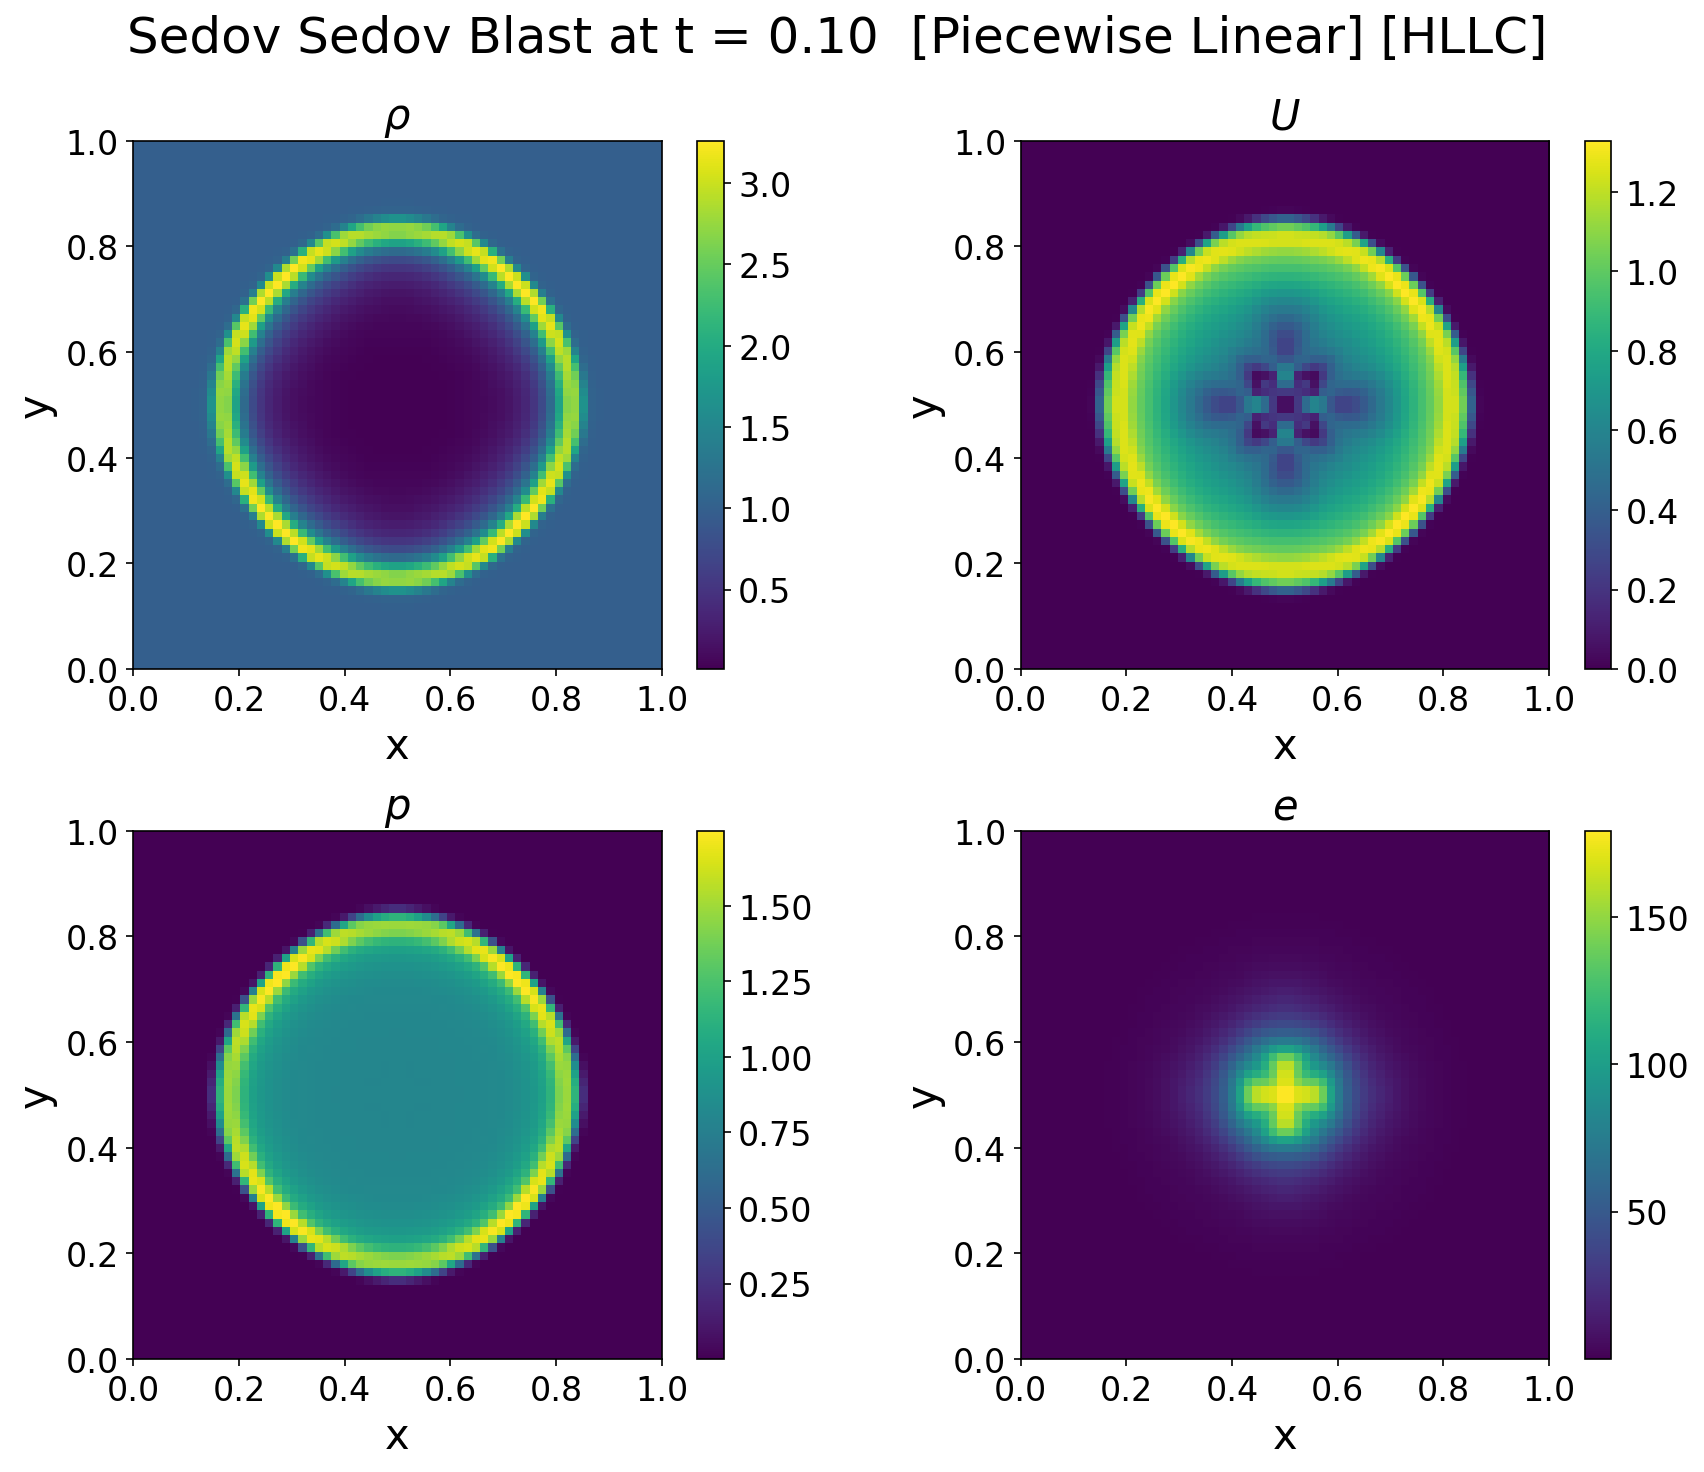

In [14]:
####################################################################################################
# Problem Parameters
####################################################################################################
# DOFs_Sedov  : conserved variables — rho, rho*u, rho*v, rho*E
# nx, ny      : interior grid resolution (128^2 gives a ~30-minute run with HLLC)
# C           : CFL number — dt = C*dx / max(|u|+c, |v|+c); must be < 1 for stability
# gamma       : ratio of specific heats (1.4 for diatomic ideal gas)
# tf          : final simulation time

DOFs_Sedov = 4
nx = 64
ny = 64
dx = 1/nx
dy = 1/ny
C = 0.8
gamma = 1.4
tf = 0.1

X = np.linspace(0,1,nx)
Y = np.linspace(0,1,ny)

####################################################################################################
# Build Ghosted Initial Condition Array
####################################################################################################
# Sedov blast IC: energy deposition at the domain center, zero velocity everywhere

#need vector valued solution vector U = (rho, rho u, rho v, rho E)
U_ghost_IC_Sedov = np.zeros((DOFs_Sedov, ny + 2*nghost, nx + 2*nghost))
U_sedov_blast = sedov_blast(U_ghost_IC_Sedov, gamma, nx, ny)
U_ghost_IC_Sedov[:, nghost:nghost+ny, nghost:nghost+nx] = U_sedov_blast[:, nghost:nghost+ny, nghost:nghost+nx] # ghosted vector able to have BCs

####################################################################################################
# Evolve and Plot
####################################################################################################
# Runs HLLC solver with PLM reconstruction (Godunov_type=1)
# HLL call is commented out but available for comparison

# U_Sol_Sedov_g1_HLL, all_solns_Sod_g1_HLL, all_t_Sod_g1_HLL = evolve(U_ghost_IC_Sedov, nx, ny, C, tf, gamma, Riemann_HLL, Godunov_type=1)
U_Sol_Sedov_g1_HLLC, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC = evolve(U_ghost_IC_Sedov, nx, ny, C, tf, gamma, Riemann_HLLC, Godunov_type=1)


# plot_solution(X, Y, U_Sol_Sedov_g1_HLL, tf, gamma, 'Sedov', 'Piecewise Linear', 'HLL')
plot_solution(X, Y, U_Sol_Sedov_g1_HLLC, tf, gamma, 'Sedov', 'Piecewise Linear', 'HLLC')


# takes 30 mins for HLLC to run with 128^2, tf = 0.1, C = 0.8, r=0.01
# but i believe it works, or is at least close.

# $\Downarrow$ Make a Movie $\Downarrow$


In [15]:
movie_maker(X, Y, all_solns_Sod_g1_HLLC, all_t_Sod_g1_HLLC, gamma, case='Sedov', Riemann='HLLC')

Saved Sedov_HLLC.gif
